# 阶段三：机器学习模型训练与评估

万事俱备，只欠东风！现在我们手里有一份完整的考题和答案（特征和是否机器人的标签）。
在这个笔记本里，我们要把数据喂给两名“AI 学生”（**逻辑回归** 和 **随机森林**），看看谁抓机器人的本事更大！

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 机器学习核心框架：Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

print("完美！Scikit-Learn 兵工厂集结完毕。")

完美！Scikit-Learn 兵工厂集结完毕。


## 1. 兵马未动，粮草先行（区分特征 X 与标签 y，并划分考卷）

做机器学习的第一步，永远是把数据劈成两块：
- **X (特征矩阵)**：就是用来判断的线索（粉丝数、正文长度等）。
- **y (目标标签)**：就是那唯一的一列标准答案（`is_bot`）。

然后，我们还要把这些数据切成**“平时作业（训练集）”**和**“期末考试（测试集）”**，通常采用 8:2 的比例。

In [2]:
# 读取上一阶段搞定的完美数据集
df = pd.read_csv('weibo-search/结果文件/中东局势彻底失控/machine_learning_ready.csv')

# 挑选出我们要让 AI 学习的特征维度（也就是 X）
feature_cols = [
    'followers_count', 'friends_count', 'statuses_count', 
    'text_len', 'exclamation_density', 'has_link', 'follower_friend_ratio', 
    'is_default_avatar', 'is_random_name', 'daily_post_rate', 'zero_engagement', 'is_verified'
]

X = df[feature_cols].fillna(0)
y = df['is_bot']

# 按照 80% 训练，20% 测试的比例划分数据
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"切分完毕！\n>> 我们给了 AI {len(X_train)} 份卷子当平时作业练习。\n>> 留下了 {len(X_test)} 份卷子作为期末考试来评测它的水平。")

切分完毕！
>> 我们给了 AI 616 份卷子当平时作业练习。
>> 留下了 154 份卷子作为期末考试来评测它的水平。


## 2. 让 AI 学生 1 号上场：逻辑回归 (Logistic Regression)

逻辑回归是最经典的算法。它会在数据里画一条线，线这边是活人，线那边是机器人。

C:\Users\欢儿\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


==== 逻辑回归的成绩单 ====
【准确率 Accuracy】: 99.35%


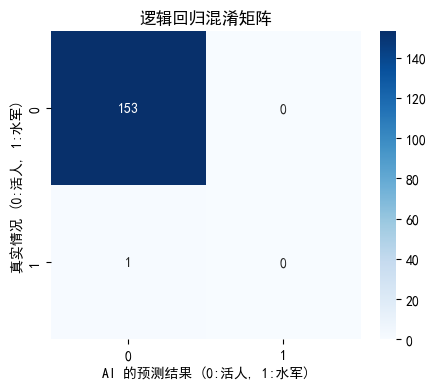

In [3]:
# 实例化一个逻辑回归模型
lr_model = LogisticRegression(max_iter=1000)

# 1. 学习过程：喂给它平时作业的 X 和 答案 y
lr_model.fit(X_train, y_train)

# 2. 考试过程：让它在没见过的 20% 期末考试题上自己填答案
y_pred_lr = lr_model.predict(X_test)

# 3. 老师判卷：自动对比 AI 预测的答案和真实的答案
print("==== 逻辑回归的成绩单 ====")
print(f"【准确率 Accuracy】: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")

# 混淆矩阵热力图（看它有没有把正常人误杀成水军）
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('逻辑回归混淆矩阵')
plt.xlabel('AI 的预测结果 (0:活人, 1:水军)')
plt.ylabel('真实情况 (0:活人, 1:水军)')
plt.show()

## 3. 让 AI 学生 2 号上场：随机森林 (Random Forest)

随机森林是数据竞赛里的大杀器。它相当于建了一千课“决策树”，每一棵树都出一道判断题，最后大家投票决定这个人是不是水军。

==== 模型已保存至 weibo_bot_rf_model.pkl ====
==== 随机森林的成绩单 ====
【准确率 Accuracy】: 100.00%

【详细报告】:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00         1

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154



C:\Users\欢儿\AppData\Local\Temp\ipykernel_12588\3089568941.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='重要程度', y='特征', data=feature_imp_df, palette='viridis')


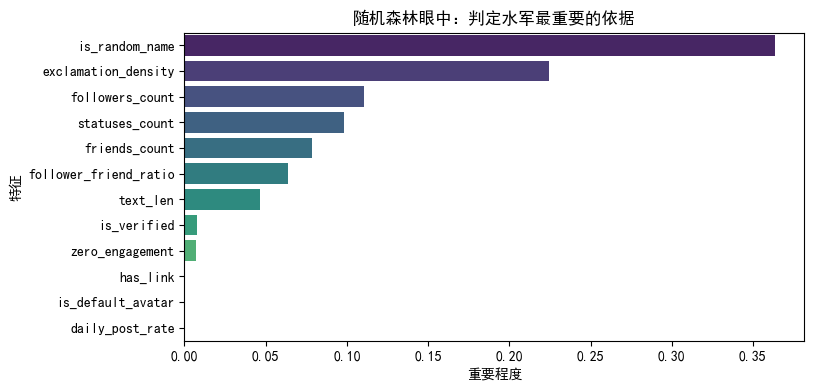

In [4]:
# 实例化一个包含 100 棵树的随机森林模型
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 学习与考试
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

import joblib
joblib.dump(rf_model, 'weibo_bot_rf_model.pkl')
print("==== 模型已保存至 weibo_bot_rf_model.pkl ====")

print("==== 随机森林的成绩单 ====")
print(f"【准确率 Accuracy】: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\n【详细报告】:\n", classification_report(y_test, y_pred_rf))

# AI 是根据什么线索抓坏人的？让随机森林交出“特征重要性”排行榜
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'特征': feature_cols, '重要程度': importances}).sort_values('重要程度', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='重要程度', y='特征', data=feature_imp_df, palette='viridis')
plt.title('随机森林眼中：判定水军最重要的依据')
plt.show()